# Wind Farm Analytics Opportunity Assessment

## 0.0 Overview

This notebook contains an exploratory analysis of wind turbine operational data from the Penmanshiel Wind Farm dataset.

The aim of the investigation is to identify data-driven opportunities to improve wind farm performance, reliability, and availability through scalable analytics solutions. Rather than focusing on a single failure event, the analysis evaluates how operational data can be used to develop reusable monitoring and predictive maintenance capabilities applicable across multiple wind farms.

## 1.0 Context 

Our company aims to provide data-driven products and services to assess the condition and 
performance of wind turbines. We regularly advise wind farms how to take action to improve 
the reliability of the sites power. As a Data Scientist in the Advanced Analytics team, you will be 
tasked with understanding clients" problems and identifying and innovating solutions to create 
new products and services. 

## 2.0 Problem

A wind farm has multiple failure’s affecting the turbines. We would like the candidate to carry 
out an exploratory analysis of the data to identify potential value adding analytic solutions that 
would improve the performance, reliability or availability of the wind farm.  

The solution should target re-useable analytics across multiple wind farms that have differing 
pain points over identification of a specific failure in the data.  

You are free to choose the most appropriate technology or tools to carry out the analysis. 
Please share a copy of your analysis ahead of the interview to allow us to review and ask 
relevant questions. Please let us know if you would prefer a git repo or a document storage link 
to share the work.

## 3.0 Objectives

The objective of this analysis is to demonstrate two failure-agnostic analytics:
1. Power-curve performance monitoring
2. Normal-behaviour/anomaly modelling

The idea is that power curve monitoring would if a turbine starts producing less power than expected at a given wind speed, something is wrong. This could then be paired with the normal-behaviour/anomaly modelling to identify systems which may be faulty.

## 4.0 Imports

In [95]:
import os
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 5.0 Constants

In [99]:
TURBINE_DATA_ROOT = r"C:/GitHub/onyx-technical-task/5946808/"
TURBINES = ["12"]
POWER_CURVE_FEATURES = [
    'Data Availability',
    'Wind speed (m/s)',
    'Wind speed, Standard deviation (m/s)',
    'Density adjusted wind speed (m/s)',
    'Power (kW)',
    'Available Capacity for Production (kW)',
    '# Date and time'
]

RATED_POWER_KW  = 2050   # Senvion MM82 nameplate; update per turbine/farm; taken from "Available Capacity for Production (Planned) (kW)"
BIN_WIDTH       = 0.5    # m/s — IEC 61400-12 standard bin width
MIN_BIN_COUNT   = 30     # minimum readings per bin for reliable statistics
ROLLING_WINDOW  = 144    # 10-min readings in 24 hours
ALERT_THRESHOLD = -5.0   # % of rated power; sustained underperformance flag

## 6.0 Functions

In [93]:
def count_status_file_rows(base_path):
    """Walks through all SCADA folders in base_path, finds Status CSVs,
    and returns:
      - detail_df: one row per file with folder, file, turbine ID, and row count
      - summary_df: total row count per turbine across all years
    """
    results = []

    for folder_name in sorted(os.listdir(base_path)):
        folder_path = os.path.join(base_path, folder_name)

        if not os.path.isdir(folder_path) or "SCADA" not in folder_name:
            continue

        for file_name in sorted(os.listdir(folder_path)):
            if not file_name.startswith("Status") or not file_name.endswith(".csv"):
                continue

            # Extract turbine ID from filename e.g. "Status_Penmanshiel_01_2016..."
            match = re.search(r"Penmanshiel_(\d{2})_", file_name)
            turbine_id = match.group(1) if match else "unknown"

            file_path = os.path.join(folder_path, file_name)
            try:
                df = pd.read_csv(file_path, header=9)
                row_count = len(df)
            except Exception as e:
                row_count = None
                print(f"ERROR reading {file_path}: {e}")

            results.append({
                "folder": folder_name,
                "file": file_name,
                "turbine_id": turbine_id,
                "row_count": row_count,
            })

    detail_df = pd.DataFrame(results)

    summary_df = (
        detail_df.groupby("turbine_id")["row_count"]
        .sum()
        .reset_index()
        .rename(columns={"row_count": "total_status_rows"})
        .sort_values("turbine_id")
    )

    return detail_df, summary_df


def load_turbine_data(base_path, turbine_id = "12"):
    """Walks through all SCADA folders in base_path and extracts all
    Turbine_Data and Status CSVs for the specified turbine, concatenating
    into two large DataFrames.

    Args:
        base_path: Root directory containing the SCADA year folders.
        turbine_id: Zero-padded turbine number string e.g. "12".

    Returns:
        data_df: All Turbine_Data rows for the turbine across all years.
        status_df: All Status rows for the turbine across all years.
    """
    data_frames = []
    status_frames = []

    for folder_name in sorted(os.listdir(base_path)):
        folder_path = os.path.join(base_path, folder_name)

        if not os.path.isdir(folder_path) or "SCADA" not in folder_name:
            continue

        for file_name in sorted(os.listdir(folder_path)):
            if not file_name.endswith(".csv"):
                continue

            # Match only files for the target turbine
            turbine_pattern = f"Penmanshiel_{turbine_id}_"
            if turbine_pattern not in file_name:
                continue

            file_path = os.path.join(folder_path, file_name)

            try:
                df = pd.read_csv(file_path, header=9)

                if file_name.startswith("Turbine_Data"):
                    data_frames.append(df)
                elif file_name.startswith("Status"):
                    status_frames.append(df)

            except Exception as e:
                print(f"ERROR reading {file_path}: {e}")

    data_df = pd.concat(data_frames, ignore_index=True) if data_frames else pd.DataFrame()
    status_df = pd.concat(status_frames, ignore_index=True) if status_frames else pd.DataFrame()

    # Sort by timestamp
    for df, time_col in [(data_df, "# Date and time"), (status_df, "Timestamp start")]:
        df[time_col] = pd.to_datetime(df[time_col])
        df.sort_values(time_col, inplace=True)
        df.reset_index(drop=True, inplace=True)

    print(f"Turbine {turbine_id}\ndata rows: {len(data_df):,} | status rows: {len(status_df):,}")

    return data_df, status_df


def null_data_across_features(df):
    missing_features = df.isna().mean().sort_values(ascending=False).mul(100)
    all_null_features = missing_features[missing_features == 100].index.tolist()
    complete_features = missing_features[missing_features == 0].index.tolist()
    
    print(f"Across the dataset {df.isnull().sum().sum()} ({round(df.isnull().sum().sum() / df.size * 100, 2)}%) of the data is missing.")

    print(f"The features which are all null ({len(all_null_features)}) are:")
    for feature in all_null_features:
        print(f"  - {feature}")
           

def plot_missing_data_over_time(
    raw_data: pd.DataFrame,
    clean_data: pd.DataFrame = None,
    turbine_name: str = "Turbine",
    datetime_feature: str = "# Date and time"
) -> None:
    """Plot the number of missing values per row over time.

    Args:
        turbine_performance_data : Turbine performance dataset.
        turbine_name : Name of the turbine to display in the plot title.

    """
    missing_data_through_time = raw_data.isna().sum(axis=1)

    plt.figure(figsize=(12, 6))

    plt.plot(
        raw_data[datetime_feature],
        missing_data_through_time,
        label="Raw Data",
        alpha=0.7
    )
    
    plt.xlabel("Date and Time")
    plt.ylabel("Number of Missing Values")
    plt.title(f"Missing Data Through Time - {turbine_name}")

    if clean_data is not None:
        clean_missing_data_through_time = clean_data.isna().sum(axis=1)
        plt.plot(
            clean_data[datetime_feature],
            clean_missing_data_through_time,
            label="Clean Data",
            alpha=0.7
        )

        plt.legend()

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


def categorise_turbine_features(df: pd.DataFrame) -> dict[str, list[str]]:
    """Categorise columns from a Penmanshiel (Greenbyte) turbine SCADA dataframe
    into sensor groups.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame already loaded from the CSV (comment lines skipped).

    Returns
    -------
    dict mapping category name -> list of column names.
    A special key '_unmatched' holds any columns that didn't fit a category.

    Example
    -------
    groups = categorise_turbine_features(df)
    for category, cols in groups.items():
        print(f"{category}: {len(cols)} features")
    """

    cols = list(df.columns)

    rules = [
        ("timestamp", [
            r"^date",
            r"^time$",
        ]),
        ("wind", [
            r"wind speed",
            r"long.?term wind",
            r"density.?adjusted wind",
        ]),
        ("direction_and_orientation", [
            r"wind direction",
            r"nacelle position",
            r"vane position",
        ]),
        ("rotor_and_mechanical", [
            r"rotor speed",
            r"generator rpm",
            r"gearbox speed",
        ]),
        ("pressures", [
            r"(bar)",
        ]),
        ("blade_pitch_and_yaw", [
            r"blade angle",
            r"pitch position",
            r"yaw bearing",
            r"gear oil.*pressure",
            r"cable winding",
        ]),
        ("power_output", [
            r"^power\b",
            r"\bpower\b.*(kw|setpoint|factor|cosphi)",
            r"(apparent|reactive) power",
            r"available capacity",
            r"ape-2",
            r"turbine power setpoint",
        ]),
        ("energy_and_lost_production", [
            r"energy export",
            r"energy import",
            r"energy budget",
            r"energy theoretical",
            r"virtual production",
            r"compensated lost",
            r"lost production",
            r"equivalent full load",
            r"production factor",
            r"performance index",
            r"capacity factor",
        ]),
        ("electrical_grid", [
            r"voltage",
            r"\bcurrent\b",
            r"motor current",
            r"grid current",
            r"grid frequency",
            r"reactive energy",
            r"power factor",
        ]),
        ("temperatures", [
            r"temperature",
            r"\btemp\b",
        ]),
        ("availability_and_performance", [
            r"avail",
            r"data availability",
            r"time.?based",
            r"production.?based",
            r"contractual",
            r"iec b\.",
            r"system avail",
        ]),
        ("structural_and_vibration", [
            r"acceleration",
            r"metal particle",
        ]),
        ("long_term_derived", [
            r"long.?term",
            r"potential power",
            r"cascading potential",
        ]),
    ]

    # Compile all patterns once
    compiled_rules = [
        (category, [re.compile(p, re.IGNORECASE) for p in patterns])
        for category, patterns in rules
    ]

    groups: dict[str, list[str]] = {category: [] for category, _ in rules}
    groups["_unmatched"] = []

    for col in cols:
        matched = False
        for category, patterns in compiled_rules:
            if any(p.search(col) for p in patterns):
                groups[category].append(col)
                matched = True
                break
        if not matched:
            groups["_unmatched"].append(col)

    # Drop empty categories for a clean result
    return {k: v for k, v in groups.items() if v}


def summarise_groups(groups: dict[str, list[str]]) -> pd.DataFrame:
    """
    Return a tidy DataFrame summarising each category.

    Columns: category, n_features, example_columns (first 3, comma-separated)
    """
    rows = []
    for category, cols in groups.items():
        rows.append({
            "category": category,
            "n_features": len(cols),
            "example_columns": ", ".join(cols[:3]),
        })
    return pd.DataFrame(rows).sort_values("n_features", ascending=False).reset_index(drop=True)


def merge_overlapping_intervals(df, start_col='Timestamp start', end_col='Timestamp end'):
    """
    Merges overlapping time intervals in a DataFrame into non-overlapping windows.
    
    Parameters:
        df: DataFrame with timestamp columns
        start_col: name of the start timestamp column
        end_col: name of the end timestamp column
    
    Returns:
        DataFrame with merged, non-overlapping intervals
    """
    # Ensure datetime types
    df = df.copy()
    df[start_col] = pd.to_datetime(df[start_col])
    df[end_col] = pd.to_datetime(df[end_col])
    
    # Sort by start time
    df_sorted = df.sort_values(start_col).reset_index(drop=True)
    
    merged = []
    current_start = df_sorted.loc[0, start_col]
    current_end = df_sorted.loc[0, end_col]
    
    for _, row in df_sorted.iloc[1:].iterrows():
        if row[start_col] <= current_end:
            # Overlapping — extend the window if needed
            current_end = max(current_end, row[end_col])
        else:
            # No overlap — save the current window and start a new one
            merged.append({start_col: current_start, end_col: current_end})
            current_start = row[start_col]
            current_end = row[end_col]
    
    # Append the final window
    merged.append({start_col: current_start, end_col: current_end})
    
    return pd.DataFrame(merged).reset_index(drop=True)


def remove_flagged_rows(data_df, windows_df,
                        data_time_col='# Date and time',
                        start_col='Timestamp start',
                        end_col='Timestamp end'):

    data_df = data_df.copy()
    timestamps = pd.to_datetime(data_df[data_time_col]).values.astype('int64')
    starts     = pd.to_datetime(windows_df[start_col]).values.astype('int64')
    ends       = pd.to_datetime(windows_df[end_col]).values.astype('int64')

    # For each timestamp, find where it would insert among the sorted starts.
    # If the interval just to its left ends after it, the timestamp is inside a window.
    idx = np.searchsorted(starts, timestamps, side='right') - 1
    in_window = (idx >= 0) & (ends[idx] >= timestamps)

    return data_df[~in_window].reset_index(drop=True)

## 7.0 Data Ingest and Inspection

The analysis uses the publicly available Penmanshiel Wind Farm dataset. The dataset contains data from a 14-turbine wind farm (14 × Senvion MM82 turbines, 28.7 MW total) with approximately 5 years of operational history, which contains:
+ Wind turbine SCADA measurements
+ Event and alarm records
+ Site-level operational data
+ Turbine metadata

Source: https://zenodo.org/records/5946808 (Published February 7, 2022 | Version 0.0.2)

During the initial investigations, to avoid spending large amounts of time managing data volume and debugging loading/formatting issues, I plan to target one turbine across its lifetimes so that periodicity is accounted. The main risk with picking one turbine is that it is unrepresentative of the fleet, however this can be assessed later.

In [77]:
detailed_df, summary_df = count_status_file_rows(TURBINE_DATA_ROOT)

summary_df.sort_values("total_status_rows")

,turbine_id,total_status_rows
10,12,31727
13,15,34266
11,13,36173
9,11,36848
6,08,38714
12,14,39142
2,04,40261
0,01,41389
4,06,44429
7,09,46701


From the brief status analysis I will pick the turbines with the least status events so that there is the most data available, so in this case Turbine 12.

In [78]:
turbine_data_dictionary = {}

for turbine_number in  TURBINES:
    data, status_logs = load_turbine_data(TURBINE_DATA_ROOT, turbine_number)
    turbine_data_dictionary[f"turbine_{turbine_number}"] = {"data": data, "status_logs": status_logs}
    print('')
    
turbine_data_dictionary.keys()

Turbine 12
data rows: 262,702 | status rows: 31,727



dict_keys(['turbine_12'])

In [79]:
display(turbine_data_dictionary["turbine_12"]["data"])

,# Date and time,Wind speed (m/s),"Wind speed, Standard deviation (m/s)","Wind speed, Minimum (m/s)","Wind speed, Maximum (m/s)",Long Term Wind (m/s),Wind speed Sensor 1 (m/s),"Wind speed Sensor 1, Standard deviation (m/s)","Wind speed Sensor 1, Minimum (m/s)","Wind speed Sensor 1, Maximum (m/s)",...,Tower Acceleration y (mm/ss),"Tower Acceleration X, Min (mm/ss)","Tower Acceleration X, Max (mm/ss)","Tower Acceleration Y, Min (mm/ss)","Tower Acceleration Y, Max (mm/ss)","Drive train acceleration, Max (mm/ss)","Drive train acceleration, Min (mm/ss)","Drive train acceleration, StdDev (mm/ss)","Tower Acceleration X, StdDev (mm/ss)","Tower Acceleration Y, StdDev (mm/ss)"
0,2016-07-02 16:20:00,0.000000,0.000000,0.000000,0.000000,5.6,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.00,NaN,NaN
1,2016-07-02 16:30:00,11.240000,1.540000,6.230000,14.910000,5.6,11.410000,1.600000,6.240000,15.230000,...,NaN,NaN,NaN,NaN,NaN,0.560000,0.260000,0.05,NaN,NaN
2,2016-07-02 16:40:00,12.620000,2.050000,8.400000,16.820000,5.6,12.820000,2.130000,8.410000,17.190001,...,NaN,NaN,NaN,NaN,NaN,0.540000,0.240000,0.05,NaN,NaN
3,2016-07-02 16:50:00,13.010000,1.920000,8.360000,18.180000,5.6,13.250000,1.930000,8.760000,18.260000,...,NaN,NaN,NaN,NaN,NaN,0.560000,0.260000,0.05,NaN,NaN
4,2016-07-02 17:00:00,13.800000,1.370000,9.680000,17.440001,5.6,13.930000,1.410000,9.920000,17.740000,...,NaN,NaN,NaN,NaN,NaN,0.530000,0.270000,0.05,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
262697,2021-06-30 23:10:00,4.160075,0.563446,2.622950,4.859900,5.8,4.338116,0.384787,3.374175,5.151366,...,14.951851,6.454197,80.422691,6.459811,24.799379,3.999716,3.999716,0.00,15.895765,5.246876
262698,2021-06-30 23:20:00,3.896270,0.442692,2.834900,4.565600,5.8,3.961304,0.336844,3.273091,4.474225,...,13.428132,6.455882,103.105927,3.536952,34.652046,4.156476,4.156476,0.00,24.470856,7.476423
262699,2021-06-30 23:30:00,3.827300,0.381297,2.948300,4.478300,5.8,3.836624,0.324582,3.135775,4.273274,...,12.433511,8.763557,101.179970,3.339933,28.427334,4.184444,4.184444,0.00,25.657130,6.599963
262700,2021-06-30 23:40:00,4.077365,0.416660,3.369050,4.960251,5.8,4.232536,0.298945,3.566600,4.796354,...,16.543479,10.015337,64.618683,5.155815,48.050697,4.330339,4.330339,0.00,15.221401,10.617524


Their are approximately 300 different features in the turbine dataset which cover a range of different categories. It would be helpful during EDA to categorise these into families like wind, power, temperatures, pressures, etc.

In [80]:
display(turbine_data_dictionary["turbine_12"]["status_logs"])

,Timestamp start,Timestamp end,Duration,Status,Code,Message,Comment,Service contract category,IEC category
0,2016-07-02 16:25:34,2016-07-05 12:00:32,67:34:58,Stop,5600,Overload hydraulic pump,NaN,Electrical error (24),Forced outage
1,2016-07-02 16:25:35,2016-07-02 16:26:16,00:00:41,Informational,3547,Overfrequency,NaN,Warnings (27),NaN
2,2016-07-02 16:25:35,2016-07-02 16:27:57,00:02:22,Warning,3875,Overload transf. fan inlet air,NaN,Warnings (27),NaN
3,2016-07-02 16:25:35,2016-07-02 16:26:42,00:01:07,Warning,2650,Overload generator fan 2,NaN,Warnings (27),Forced outage
4,2016-07-02 16:25:35,2016-07-02 16:26:42,00:01:07,Warning,2655,Overload generator fan 3,NaN,Warnings (27),Forced outage
...,...,...,...,...,...,...,...,...,...
31722,2021-06-30 22:14:46,-,-,Informational,100130,Automatic start-up,NaN,NaN,Full Performance
31723,2021-06-30 22:34:01,-,-,Informational,100180,Run-up,NaN,NaN,Technical Standby
31724,2021-06-30 22:35:48,-,-,Informational,100190,Mains connection,NaN,NaN,Full Performance
31725,2021-06-30 22:35:59,-,-,Informational,100200,Mains run-up,NaN,NaN,Full Performance


On manually inspecting the status logs I can see that the first entry has both the start and the end timestamp for an event, indicating that this is the main descriptor for that log, so could be used to identify the 'number of events'

## 8.0 Exploratory Data Analysis

### 8.1 Duplicates & Missing Timestamps

In [81]:
for turbine in turbine_data_dictionary.keys():
    print(turbine.upper())
    data = turbine_data_dictionary[turbine]["data"]
    
    number_of_rows = len(data)
    data["# Date and time"] = pd.to_datetime(data["# Date and time"])
    duplicates = data["# Date and time"].duplicated().sum()
    diffs = data["# Date and time"].diff()
    
    print(f"The turbine dataset contains {number_of_rows} rows with {duplicates} duplicate timestamps.")
    print(f"The turbine dataset starts at {min(data["# Date and time"])} and ends at {max(data["# Date and time"])}")
    print(f"The time intervals are intended to be every 10 minutes. The breakdown of the time intervals is as follows:\n\n{diffs.value_counts()}\n")

TURBINE_12
The turbine dataset contains 262702 rows with 0 duplicate timestamps.
The turbine dataset starts at 2016-07-02 16:20:00 and ends at 2021-06-30 23:50:00
The time intervals are intended to be every 10 minutes. The breakdown of the time intervals is as follows:

# Date and time
0 days 00:10:00    262701
Name: count, dtype: int64



In [82]:
for turbine in turbine_data_dictionary.keys():
    print(turbine.upper())
    status_logs = turbine_data_dictionary[turbine]["status_logs"]
    
    events = status_logs.loc[status_logs["Timestamp end"] != "-"]
    event_finish_times = pd.to_datetime(events["Timestamp end"])

    print(f"A total of {len(event_finish_times)} events occur from {min(event_finish_times)} to {max(event_finish_times)}.\n\n")

TURBINE_12
A total of 7676 events occur from 2016-07-02 16:26:10 to 2021-06-30 22:14:46.




There appears to be no duplicate timestamps across the turbine dataset and both the turbine data and the status logs cover the expected range of the data.

### 8.2 Null Data Across Features

In [83]:
for turbine in turbine_data_dictionary.keys():
    print(turbine)
    null_data_across_features(turbine_data_dictionary[turbine]["data"])
    print("")

turbine_12
Across the dataset 22999367 (29.18%) of the data is missing.
The features which are all null (9) are:
  - Equivalent Full Load Hours counter (s)
  - Lost Production (Contractual Custom) (kWh)
  - Potential power met mast anemometer (kW)
  - Production-based Contractual Avail. (Custom)
  - Production-based Contractual Avail. (Global)
  - Time-based Contractual Avail. (Custom)
  - Time-based Contractual Avail. (Global)
  - Lost Production (Contractual Global) (kWh)
  - Potential power met mast anemometer MPC (kW)



In [84]:
for turbine in turbine_data_dictionary.keys():
    print(turbine)
    status_logs = turbine_data_dictionary[turbine]["status_logs"]
    
    missing_features = status_logs.isna().mean().sort_values(ascending=False).mul(100)
    all_null_features = missing_features[missing_features == 100].index.tolist()
    
    print(f"\nThere are a total of {len(all_null_features)} features which contain no data, these include:")
    
    for feature in all_null_features:
        print(f"    - {feature}")
    print("")

turbine_12

There are a total of 1 features which contain no data, these include:
    - Comment



### 8.3 Data Availability

In [85]:
for turbine in turbine_data_dictionary.keys():
    print(turbine)
    data = turbine_data_dictionary[turbine]["data"]
    status_logs = turbine_data_dictionary[turbine]["status_logs"]
    
    non_available = len(data.loc[data["Data Availability"] == 0])
    non_available_pct = round(100 * non_available / number_of_rows, 2)
    
    print(f"There are {non_available} ({non_available_pct}%) timestamps labelled as having no data available.") 
    print(f"Across the dataset {data.isnull().sum().sum()} ({round(data.isnull().sum().sum() / data.size * 100, 2)}%) of the data is missing.\n")

turbine_12
There are 10464 (3.98%) timestamps labelled as having no data available.
Across the dataset 22999367 (29.18%) of the data is missing.



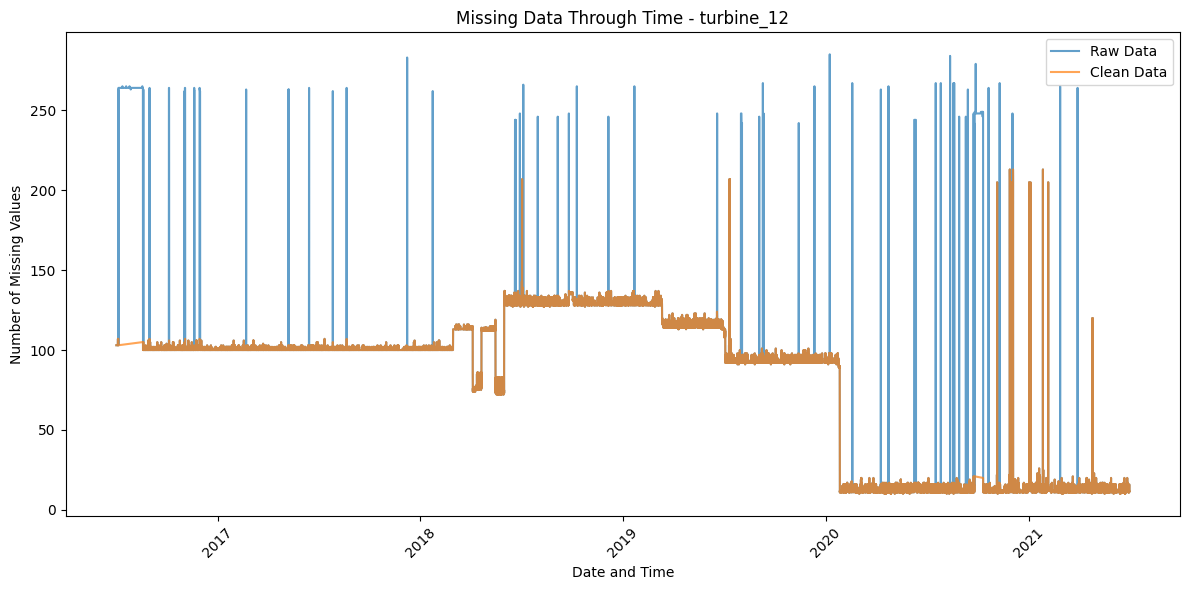

In [86]:
for turbine in turbine_data_dictionary.keys():
    data = turbine_data_dictionary[turbine]["data"]

    plot_missing_data_over_time(
        data,
        data.loc[data["Data Availability"] == 1],
        turbine
    )

The rolling median/average of missing values appears to have step changes over time, which is consistent across the fleet. I would suspect that this is down to maintenance activities so it's worth checking against the status logs in a future investigation.

Lots of outliers / blips in the data which can be mitigated / removed by the "Data Availability" filter. Also worth checking these points against the status logs in a future investigation.

Moving forwards I propose to remove the data tagged as unavailable as opposed to interpolating as it only makes up ~4% of the dataset so shouldn't have too large an effect on model performance.

### 8.4 Feature Categories

In [87]:
groups = categorise_turbine_features(turbine_data_dictionary["turbine_12"]["data"])
print(summarise_groups(groups).to_string(index=False))

                    category  n_features                                                                                            example_columns
                temperatures          76                   Front bearing temperature (°C), Rear bearing temperature (°C), Stator temperature 1 (°C)
             electrical_grid          48                                                 Voltage L1 / U (V), Voltage L2 / V (V), Voltage L3 / W (V)
  energy_and_lost_production          43                                      Energy Export (kWh), Energy Export counter (kWh), Energy Import (kWh)
                power_output          34                                Power (kW), Potential power default PC (kW), Power, Standard deviation (kW)
         blade_pitch_and_yaw          20 Blade angle (pitch position) A (°), Blade angle (pitch position) B (°), Blade angle (pitch position) C (°)
availability_and_performance          18                        Data Availability, Time-based Contractual Avail.

In [88]:
groups

{'wind': ['Wind speed (m/s)',
  'Wind speed, Standard deviation (m/s)',
  'Wind speed, Minimum (m/s)',
  'Wind speed, Maximum (m/s)',
  'Long Term Wind (m/s)',
  'Wind speed Sensor 1 (m/s)',
  'Wind speed Sensor 1, Standard deviation (m/s)',
  'Wind speed Sensor 1, Minimum (m/s)',
  'Wind speed Sensor 1, Maximum (m/s)',
  'Wind speed Sensor 2 (m/s)',
  'Wind speed Sensor 2, Standard deviation (m/s)',
  'Wind speed Sensor 2, Minimum (m/s)',
  'Wind speed Sensor 2, Maximum (m/s)',
  'Density adjusted wind speed (m/s)'],
 'direction_and_orientation': ['Wind direction (°)',
  'Nacelle position (°)',
  'Wind direction, Standard deviation (°)',
  'Wind direction, Minimum (°)',
  'Wind direction, Maximum (°)',
  'Nacelle position, Standard deviation (°)',
  'Nacelle position, Minimum (°)',
  'Nacelle position, Maximum (°)',
  'Vane position 1+2 (°)',
  'Vane position 1+2, Max (°)',
  'Vane position 1+2, Min (°)',
  'Vane position 1+2, StdDev (°)'],
 'rotor_and_mechanical': ['Rotor speed (RPM)

As I intend to look into Power-Curve monitoring I will select a sub-set of these features: 'Data Availability', 'Wind speed (m/s)', 'Wind speed, Standard deviation (m/s)', 'Density adjusted wind speed (m/s)', 'Power (kW)' and '# Date and Time'. 

Then when modelling normal behaviour, important features from each category could be modelled to then pair with the power curve analysis and identify potential faults.

### 8.5 Failure Log

In [89]:
for turbine in turbine_data_dictionary.keys():
    print(turbine.upper())
    status_logs = turbine_data_dictionary[turbine]["status_logs"]
    events = status_logs.loc[status_logs["Timestamp end"] != "-"].copy()
    turbine_data_dictionary[turbine]["events"] = events

    print(f"{events["Status"].value_counts()}\n")

TURBINE_12
Status
Informational    6201
Stop              982
Warning           444
Communication      49
Name: count, dtype: int64



### 8.6 Raw Power Curve

The features of importance when calculating the power curve are:
- **# Date and time**
- **Wind speed (m/s)**: the input to the curve. This is the anemometer-average over the 10-minute window.
- **Density adjusted wind speed (m/s)**: air density changes with temperature and altitude, so at the same "raw" wind speed, a cold dense morning produces more power than a warm afternoon.
- **Wind speed, Standard deviation (m/s)**: The wind can be turbulent in a 10-minute window, a high standard deviation means the wind was gusty and the turbine was accelerating/decelerating. These readings produce noisy, unreliable power measurements and should be filtered out, a common threshold is std dev > 2m/s before fitting the baseline curve. Including them would inflate the scatter around "normal" and make anomalies harder to detect.
- **Power (kW)**: the output. The whole method is built on the relationship between this and wind speed.
- **Available Capacity for Production (kW)**: Used to compare against the rated power which was derived from Available Capacity for Production (Planned) (kW), where the available capacity does not meet the planned capacity by a given threshold, filter out this data.

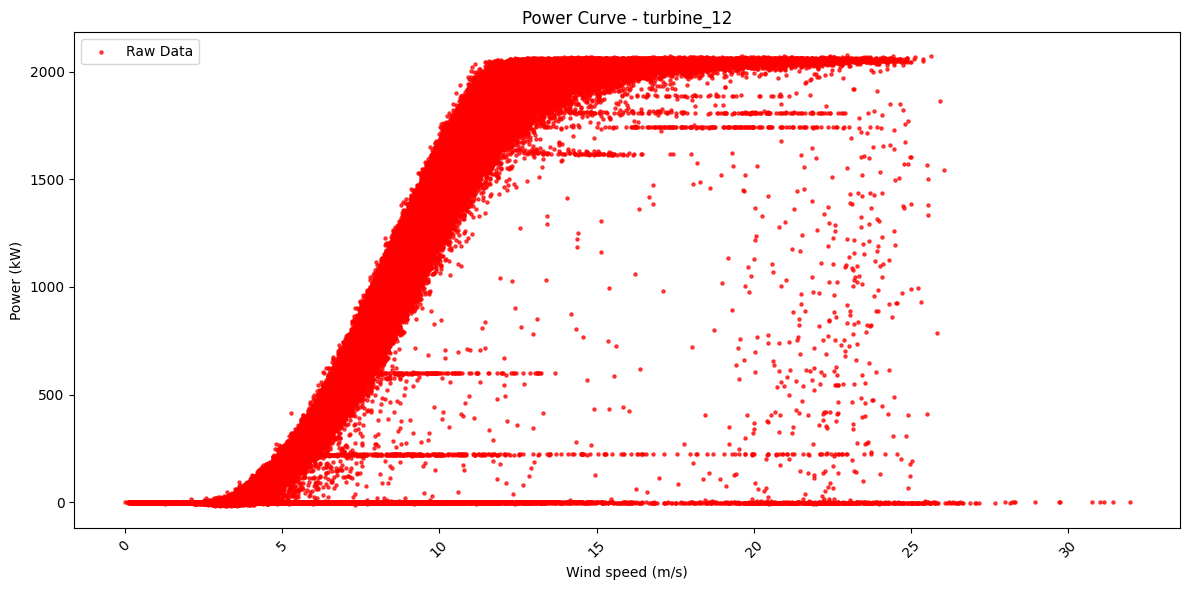

In [128]:
for turbine in turbine_data_dictionary.keys():
    data = turbine_data_dictionary[turbine]["data"]

    plt.figure(figsize=(12, 6))

    plt.scatter(
        raw_power_data["Wind speed (m/s)"],
        raw_power_data["Power (kW)"],
        label="Raw Data",
        alpha=0.7,
        color="red",
        s=5
    )
        
    plt.xlabel("Wind speed (m/s)")
    plt.ylabel("Power (kW)")
    plt.title(f"Power Curve - {turbine}")

    plt.legend(loc="upper left")

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### 8.7 Baseline Selection

This section discusses the filtering logic and window choice with it's justification and validation (clean-reading count and bin coverage). 

To identify periods of normal operation, any status events which indicate non-normal conditions should be identified and removed from the dataset. I will define these as:
- Any time periods logged in the status logs.
- Any timestamps where data availability = 0.
- Any timestamps where the std dev of the wind speed is >= 2 m/s
- Any timestamps where the available capacity for production does not meet the planned capacity * 0.99 (1%)

TURBINE_12
         Timestamp start       Timestamp end
0    2016-07-02 16:25:34 2016-09-26 15:02:43
1    2016-09-26 15:07:04 2016-11-02 18:11:24
2    2016-11-02 20:54:34 2018-04-10 07:26:02
3    2018-04-10 08:51:54 2018-05-30 22:25:09
4    2018-05-31 01:34:26 2018-05-31 01:35:14
...                  ...                 ...
2946 2021-06-29 13:54:47 2021-06-29 13:55:35
2947 2021-06-30 15:43:36 2021-06-30 15:44:24
2948 2021-06-30 19:21:55 2021-06-30 19:22:43
2949 2021-06-30 21:56:07 2021-06-30 21:56:55
2950 2021-06-30 22:13:59 2021-06-30 22:14:46

[2951 rows x 2 columns]

Removing the data which has a status log against it reduced the dataset by 122281 rows, which is 46.55% of the data.
Leaving 140421 records.
With the additional filters applied this leaves 126508 rows, which is 48.16%.


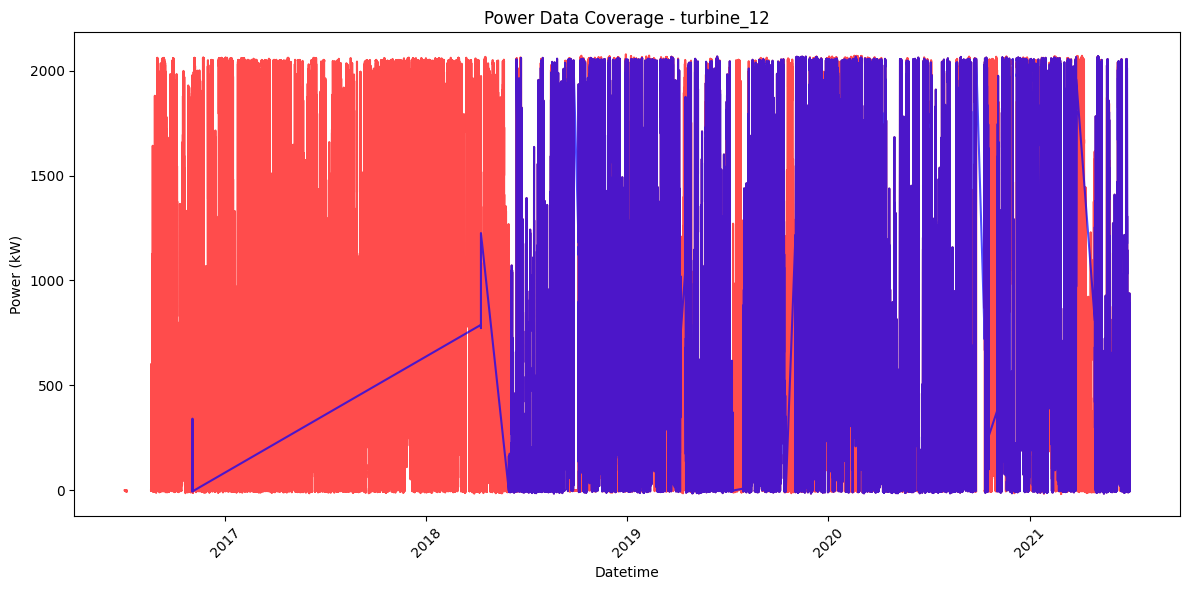

In [134]:
for turbine in turbine_data_dictionary.keys():
    print(turbine.upper())
    data = turbine_data_dictionary[turbine]["data"]
    events = turbine_data_dictionary[turbine]["events"]
    non_normal_events = events.loc[
        (events["Status"] == "Stop") 
        | (events["Status"] == "Warning")
        | (events["Status"] == "Communication")
        | (events["Status"] == "Informational")
    ].copy()
    clean_windows = merge_overlapping_intervals(non_normal_events)
    print(clean_windows)
    print('')
    normal_operating = remove_flagged_rows(data, clean_windows)
    turbine_data_dictionary[turbine]["normal_operating"] = normal_operating

    print(f"Removing the data which has a status log against it reduced the dataset by {len(data) - len(normal_operating)} rows, which is {round(100*(len(data) - len(normal_operating))/len(data), 2)}% of the data.")
    print(f"Leaving {len(normal_operating)} records.")

    filtered_normal_operating = normal_operating[
        (normal_operating["Data Availability"] == 1)
        & (normal_operating["Wind speed, Standard deviation (m/s)"] < 2.0)
        & (normal_operating["Available Capacity for Production (kW)"] >= RATED_POWER_KW * 0.99)
    ].copy()

    print(f"With the additional filters applied this leaves {len(filtered_normal_operating)} rows, which is {round(100*(len(filtered_normal_operating))/len(data), 2)}%.")

    plt.figure(figsize=(12, 6))

    plt.plot(
        data["# Date and time"],
        data["Power (kW)"],
        alpha=0.7,
        color="red",
        label="Raw Data"
    )

    plt.plot(
        filtered_normal_operating["# Date and time"],
        filtered_normal_operating["Power (kW)"],
        alpha=0.7,
        color="blue",
        label="Filtered Data"
    )
        
    plt.xlabel("Datetime")
    plt.ylabel("Power (kW)")
    plt.title(f"Power Data Coverage - {turbine}")

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Although these filters remove a large chunk of the data, leaving only ~50%, there is still enough to determine expected normal operating conditions. The majority of the data removed is from prior to Q2/Q3 2018, so we essentially have 'clean' data for Q3 2018 onwards, with only small gaps moving forwards.

In [136]:
from datetime import datetime as dt

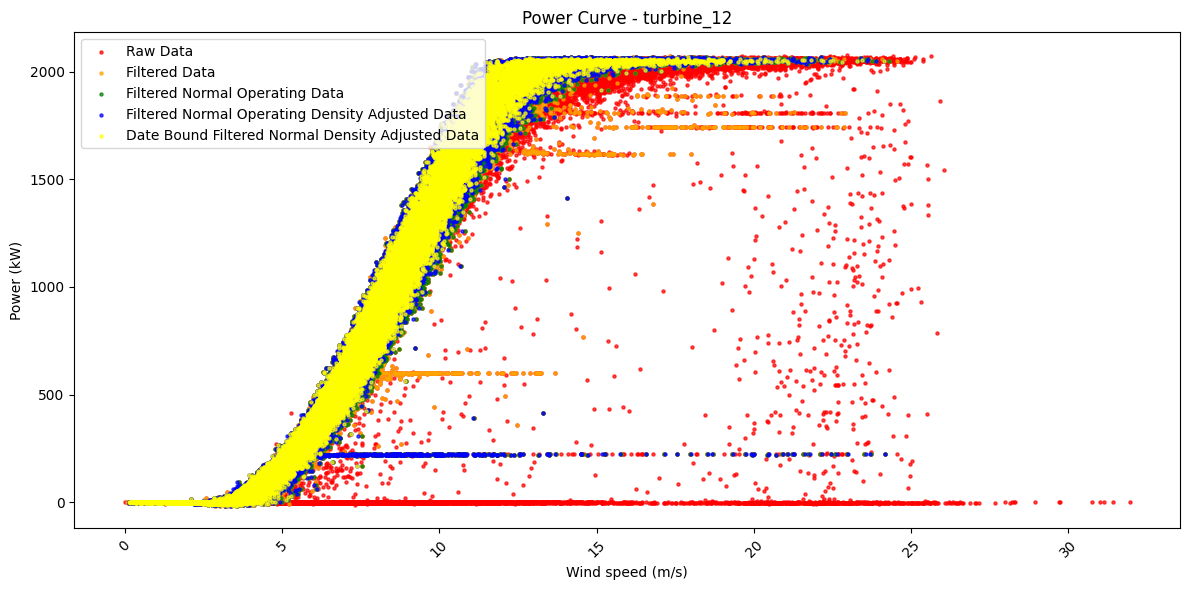

In [150]:
for turbine in turbine_data_dictionary.keys():
    data = turbine_data_dictionary[turbine]["data"]
    raw_power_data = data[POWER_CURVE_FEATURES].copy()
    filtered_power_data = raw_power_data[
        (raw_power_data["Data Availability"] == 1) &
        (raw_power_data["Wind speed, Standard deviation (m/s)"] < 2.0) &
        (raw_power_data["Available Capacity for Production (kW)"] >= RATED_POWER_KW * 0.99)
    ].copy()

    normal_operating_power_data = turbine_data_dictionary[turbine]["normal_operating"][POWER_CURVE_FEATURES].copy()

    filtered_normal_operating_power_data = normal_operating_power_data[
        (normal_operating_power_data["Data Availability"] == 1) &
        (normal_operating_power_data["Wind speed, Standard deviation (m/s)"] < 2.0) &
        (normal_operating_power_data["Available Capacity for Production (kW)"] >= RATED_POWER_KW * 0.99)
    ].copy()

    date_bound_normal_data = filtered_normal_operating_power_data[
        (filtered_normal_operating_power_data["# Date and time"] < dt(2019, 6, 1))
        & (filtered_normal_operating_power_data["# Date and time"] > dt(2018, 6, 1))
    ].copy()
    
    plt.figure(figsize=(12, 6))

    plt.scatter(
        raw_power_data["Wind speed (m/s)"],
        raw_power_data["Power (kW)"],
        label="Raw Data",
        alpha=0.7,
        color="red",
        s=5
    )

    plt.scatter(
        filtered_power_data["Wind speed (m/s)"],
        filtered_power_data["Power (kW)"],
        label="Filtered Data",
        alpha=0.7,
        color="orange",
        s=5
    )

    plt.scatter(
        filtered_normal_operating_power_data["Wind speed (m/s)"],
        filtered_normal_operating_power_data["Power (kW)"],
        label="Filtered Normal Operating Data",
        alpha=0.7,
        color="green",
        s=5
    )

    plt.scatter(
        filtered_normal_operating_power_data["Density adjusted wind speed (m/s)"],
        filtered_normal_operating_power_data["Power (kW)"],
        label="Filtered Normal Operating Density Adjusted Data",
        alpha=0.7,
        color="blue",
        s=5
    )

    plt.scatter(
        date_bound_normal_data["Density adjusted wind speed (m/s)"],
        date_bound_normal_data["Power (kW)"],
        label="Date Bound Filtered Normal Density Adjusted Data",
        alpha=0.7,
        color="yellow",
        s=5
    )
        
    plt.xlabel("Wind speed (m/s)")
    plt.ylabel("Power (kW)")
    plt.title(f"Power Curve - {turbine}")

    plt.legend(loc="upper left")

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    turbine_data_dictionary[turbine]["baseline"] = date_bound_normal_data

It can be seen that through cleaning the data, filtering out 'noisy' timestamps with large standard deviations in wind speed and available capacity discrepencies, applying the density adjusted wind speed, and removing 'Stop' and 'Warning' periods, the power curve begins to take more of the expected S-curve shape.

There are still anomalies below 500kW of power where it does not follow the curve, this may be due to limits being exceeded elsewhere in the dataset.

By selecting the Q3 2018 - Q2 2019 time period, these anomalies are removed and this is the dataset which I am proposing for my baseline power-curve.


Bin coverage summary — turbine_12
  Total bins         : 51
  Well-populated (>=30): 36
  Under-populated    : 12
  Empty              : 3
  Wind speed range   : 0.0 – 18.0 m/s


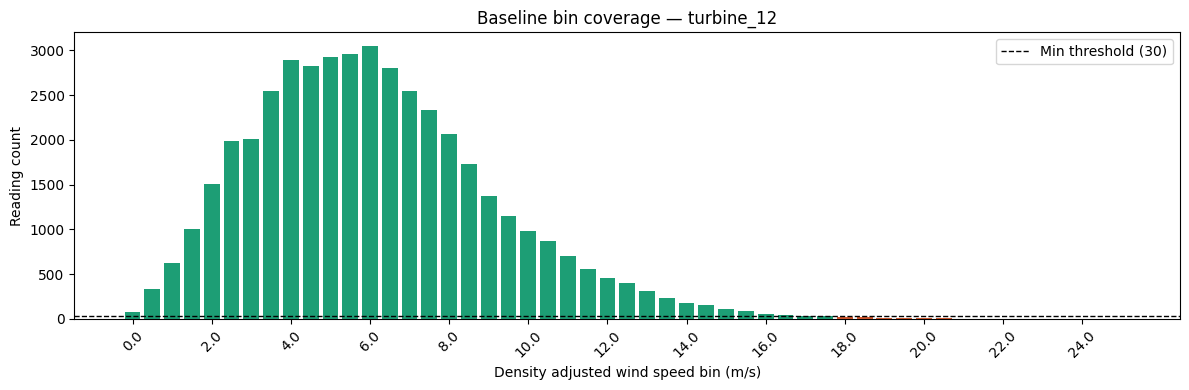

In [139]:
for turbine in turbine_data_dictionary.keys():
    data = turbine_data_dictionary[turbine]["data"]
    raw_power_data = data[POWER_CURVE_FEATURES].copy()

    normal_operating_power_data = turbine_data_dictionary[turbine]["normal_operating"][POWER_CURVE_FEATURES].copy()

    filtered_normal_operating_power_data = normal_operating_power_data[
        (normal_operating_power_data["Data Availability"] == 1) &
        (normal_operating_power_data["Wind speed, Standard deviation (m/s)"] < 2.0) &
        (normal_operating_power_data["Available Capacity for Production (kW)"] >= RATED_POWER_KW * 0.99)
    ].copy()

    date_bound_normal_data = filtered_normal_operating_power_data[
        (filtered_normal_operating_power_data["# Date and time"] < dt(2019, 6, 1))
        & (filtered_normal_operating_power_data["# Date and time"] > dt(2018, 6, 1))
    ].copy()
    
    # ── Bin coverage validation ───────────────────────────────────────────────
    bins = np.arange(0, 26, BIN_WIDTH)

    date_bound_normal_data["ws_bin"] = pd.cut(
        date_bound_normal_data["Density adjusted wind speed (m/s)"],
        bins=bins
    )

    bin_counts = (
        date_bound_normal_data
        .groupby("ws_bin", observed=False)
        .size()
        .rename("count")
        .reset_index()
    )

    well_populated = bin_counts[bin_counts["count"] >= MIN_BIN_COUNT]
    under_populated = bin_counts[
        (bin_counts["count"] > 0) & (bin_counts["count"] < MIN_BIN_COUNT)
    ]
    empty = bin_counts[bin_counts["count"] == 0]

    print(f"\nBin coverage summary — {turbine}")
    print(f"  Total bins         : {len(bin_counts)}")
    print(f"  Well-populated (>={MIN_BIN_COUNT}): {len(well_populated)}")
    print(f"  Under-populated    : {len(under_populated)}")
    print(f"  Empty              : {len(empty)}")
    if len(well_populated):
        print(f"  Wind speed range   : "
              f"{well_populated['ws_bin'].iloc[0].left:.1f} – "
              f"{well_populated['ws_bin'].iloc[-1].right:.1f} m/s")

    # Bar chart — count per bin, threshold line
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(
        range(len(bin_counts)),
        bin_counts["count"],
        color=["#1D9E75" if c >= MIN_BIN_COUNT else "#D85A30"
               for c in bin_counts["count"]],
        width=0.8
    )
    ax.axhline(MIN_BIN_COUNT, color="black", linestyle="--",
               linewidth=1, label=f"Min threshold ({MIN_BIN_COUNT})")
    ax.set_xticks(range(0, len(bin_counts), 4))
    ax.set_xticklabels(
        [f"{bins[i]:.1f}" for i in range(0, len(bin_counts), 4)],
        rotation=45
    )
    ax.set_xlabel("Density adjusted wind speed bin (m/s)")
    ax.set_ylabel("Reading count")
    ax.set_title(f"Baseline bin coverage — {turbine}")
    ax.legend()
    plt.tight_layout()
    plt.show()

The baseline is well-covered across the operating range. 36 of 51 bins are well-populated (>=30 readings), covering 0–18 m/s. The turbine's rated power is reached somewhere around 12–13 m/s, so everything that matters for the power curve shape has robust statistics behind it.

The under-populated and empty bins are in the right places. The 12 under-populated and 3 empty bins are all at the extremes. The very low end (near cut-in, where the turbine is just starting up) and above 18 m/s (near cut-out, where it's rare to operate). These are the least important parts of the curve for detecting underperformance, since turbines spend very little time there.

## 9.0 Modelling the Power Curve

### 9.1 Building the Baseline Power Curve

This section bins the baseline data and fits the per-bin statistics, then stores the results back into the dictionary so the power-curve monitor can use it.

turbine_12: 36 bins fitted
  Coverage: 0.2 – 17.8 m/s


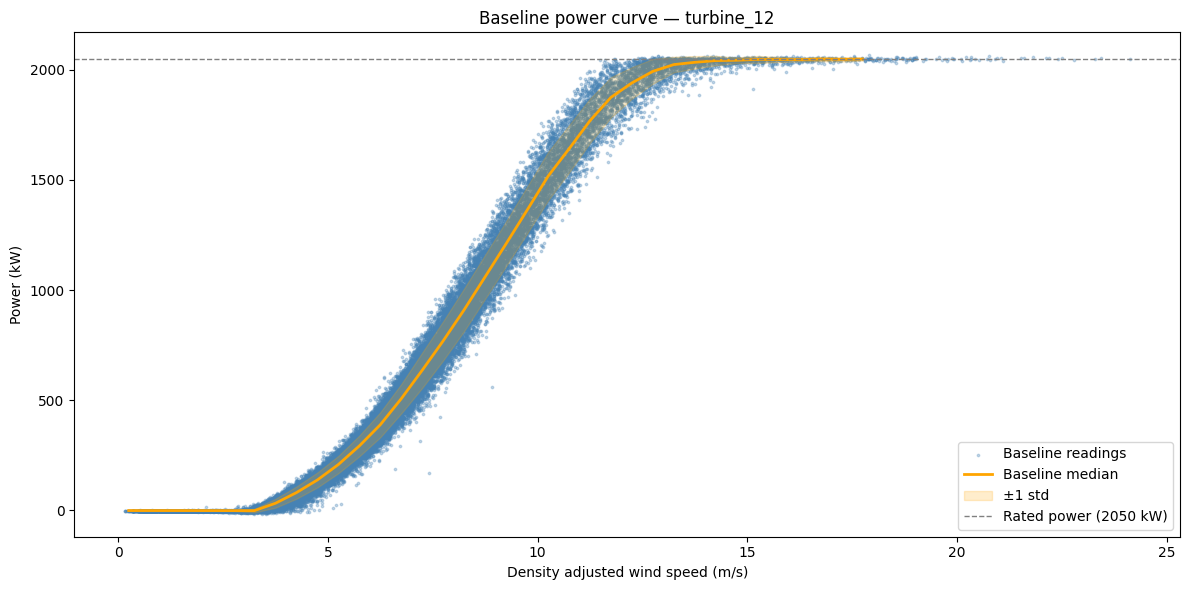

In [142]:
for turbine in turbine_data_dictionary.keys():
    baseline = turbine_data_dictionary[turbine]["baseline"]

    # Bin edges — extend one step beyond observed max so no readings fall outside
    max_ws = baseline["Density adjusted wind speed (m/s)"].max()
    upper_edge = np.ceil(max_ws / BIN_WIDTH) * BIN_WIDTH + BIN_WIDTH
    bins = np.arange(0, upper_edge, BIN_WIDTH)

    baseline = baseline.copy()
    baseline["ws_bin"] = pd.cut(
        baseline["Density adjusted wind speed (m/s)"], bins=bins
    )

    # Per-bin median, std and count
    baseline_curve = (
        baseline
        .groupby("ws_bin", observed=False)["Power (kW)"]
        .agg(median="median", std="std", count="count")
        .reset_index()
    )

    # Drop bins below the minimum sample threshold — unreliable statistics
    baseline_curve = baseline_curve[
        baseline_curve["count"] >= MIN_BIN_COUNT
    ].copy()
    baseline_curve["ws_mid"] = baseline_curve["ws_bin"].apply(lambda x: x.mid)

    # Store for monitor
    turbine_data_dictionary[turbine]["baseline_curve"] = baseline_curve
    turbine_data_dictionary[turbine]["bins"] = bins

    print(f"{turbine}: {len(baseline_curve)} bins fitted")
    print(f"  Coverage: {baseline_curve['ws_mid'].min():.1f} – "
          f"{baseline_curve['ws_mid'].max():.1f} m/s")

    # Plot fitted curve over baseline scatter
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.scatter(
        baseline["Density adjusted wind speed (m/s)"], baseline["Power (kW)"],
        s=3, alpha=0.3, color="steelblue", label="Baseline readings"
    )
    ax.plot(
        baseline_curve["ws_mid"], baseline_curve["median"],
        color="orange", linewidth=2, label="Baseline median"
    )
    ax.fill_between(
        baseline_curve["ws_mid"],
        baseline_curve["median"] - baseline_curve["std"],
        baseline_curve["median"] + baseline_curve["std"],
        alpha=0.2, color="orange", label="±1 std"
    )
    ax.axhline(RATED_POWER_KW, color="gray", linestyle="--",
               linewidth=1, label=f"Rated power ({RATED_POWER_KW} kW)")
    ax.set_xlabel("Density adjusted wind speed (m/s)")
    ax.set_ylabel("Power (kW)")
    ax.set_title(f"Baseline power curve — {turbine}")
    ax.legend()
    plt.tight_layout()
    plt.show()

### 9.2 The Monitor

This section scores all filtered data against the baseline, computes the rolling performance score, and plots it.


turbine_12
  Readings scored       : 216,705
  Mean residual         : -0.18%
  Readings below alert  : 971


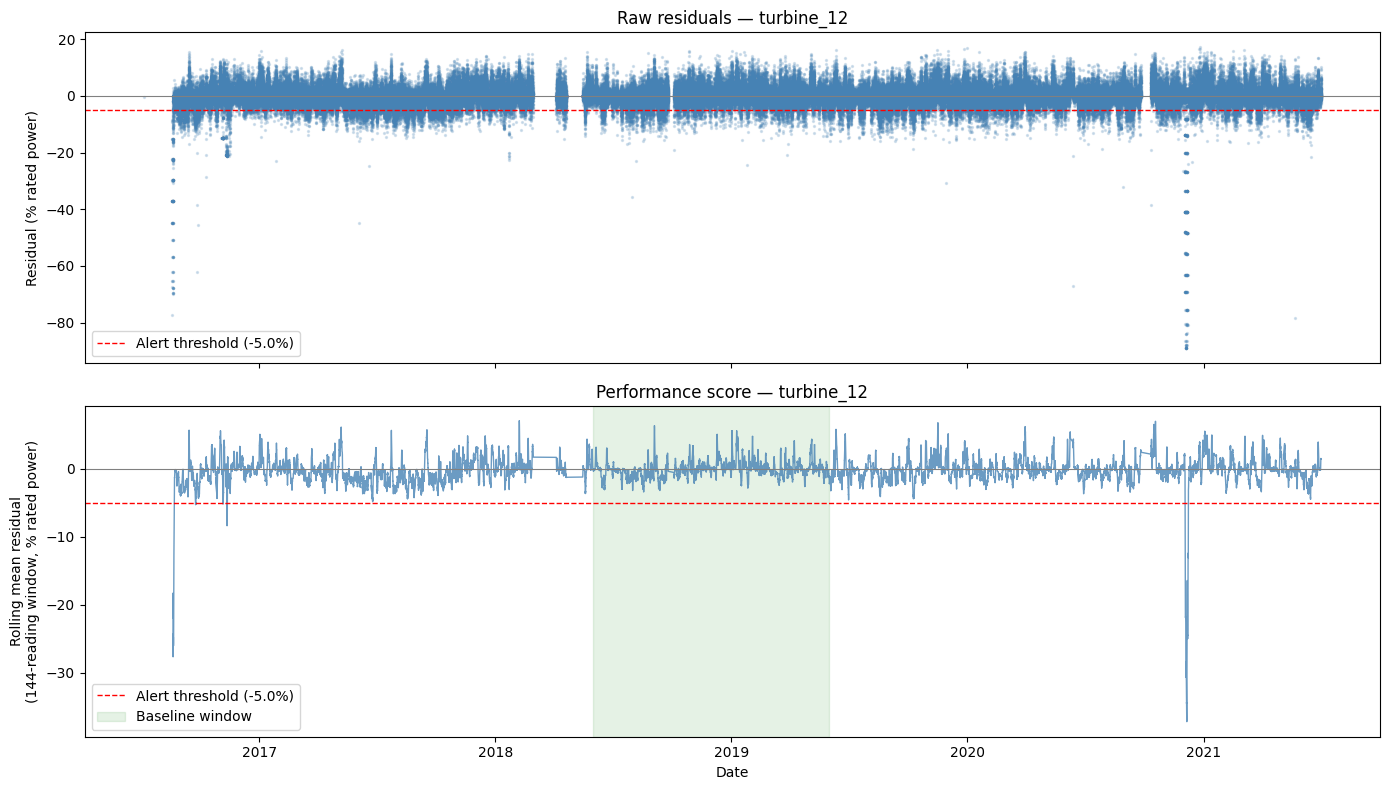

In [162]:
for turbine in turbine_data_dictionary.keys():
    baseline_curve = turbine_data_dictionary[turbine]["baseline_curve"]
    bins = turbine_data_dictionary[turbine]["bins"]
    full_data = turbine_data_dictionary[turbine]["data"].copy()
    full_data["# Date and time"] = pd.to_datetime(full_data["# Date and time"])

    scored = full_data[
        (full_data["Data Availability"] == 1)
        & (full_data["Wind speed, Standard deviation (m/s)"] < 2.0)
        & (full_data["Available Capacity for Production (kW)"] >= RATED_POWER_KW * 0.99)
    ].copy()

    # Assign wind speed bins
    scored["ws_bin"] = pd.cut(
        scored["Density adjusted wind speed (m/s)"], bins=bins
    )

    # Look up expected power — readings outside baseline coverage become NaN
    lookup = baseline_curve.set_index("ws_bin")["median"]
    scored["expected_power"] = scored["ws_bin"].map(lookup)
    scored = scored.dropna(subset=["expected_power"])

    # Residual normalised by rated power → comparable across turbine sizes
    scored["residual_pct"] = (
        (scored["Power (kW)"] - scored["expected_power"]) / RATED_POWER_KW * 100
    )

    # Rolling mean — smooths noise, surfaces sustained underperformance
    scored = scored.sort_values("# Date and time").reset_index(drop=True)
    scored["performance_score"] = scored["residual_pct"].rolling(
        window=ROLLING_WINDOW, min_periods=ROLLING_WINDOW // 2
    ).mean()

    turbine_data_dictionary[turbine]["scored"] = scored

    print(f"\n{turbine}")
    print(f"  Readings scored       : {len(scored):,}")
    print(f"  Mean residual         : {scored['residual_pct'].mean():.2f}%")
    print(f"  Readings below alert  : "
          f"{(scored['performance_score'] < ALERT_THRESHOLD).sum():,}")

    # ── Plot ─────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # Top panel — raw residuals
    axes[0].scatter(
        scored["# Date and time"], scored["residual_pct"],
        s=2, alpha=0.2, color="steelblue"
    )
    axes[0].axhline(0, color="gray", linewidth=0.8)
    axes[0].axhline(ALERT_THRESHOLD, color="red", linestyle="--",
                    linewidth=1, label=f"Alert threshold ({ALERT_THRESHOLD}%)")
    axes[0].set_ylabel("Residual (% rated power)")
    axes[0].set_title(f"Raw residuals — {turbine}")
    axes[0].legend()

    # Bottom panel — rolling mean performance score
    axes[1].plot(
        scored["# Date and time"], scored["performance_score"],
        color="steelblue", linewidth=1, alpha=0.8
    )
    axes[1].axhline(0, color="gray", linewidth=0.8)
    axes[1].axhline(ALERT_THRESHOLD, color="red", linestyle="--",
                    linewidth=1, label=f"Alert threshold ({ALERT_THRESHOLD}%)")
    axes[1].axvspan(
        dt(2018, 6, 1), dt(2019, 6, 1),
        alpha=0.1, color="green", label="Baseline window"
    )
    axes[1].set_ylabel(
        f"Rolling mean residual\n({ROLLING_WINDOW}-reading window, % rated power)"
    )
    axes[1].set_xlabel("Date")
    axes[1].set_title(f"Performance score — {turbine}")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

In production the pipeline would be run on all incoming data, but only pass a reading through to the scoring step if it meets the quality filters. A reading that fails the filters tells you nothing meaningful about performance. Scoring it would produce a spurious residual that pollutes the rolling mean and could trigger false alerts. So those readings get dropped from scoring, not from storage.

The distinction matters because the reasons a reading gets filtered are themselves valuable signals. A turbine that spends 40% of its time with Data Availability = 0 in a given month has an availability problem worth surfacing separately, even though none of those rows feed the power curve monitor. If filtered before ingestion we'd lose that visibility.

## 10. Results and Demonstration

### 10.1 Sanity Check

The baseline window should sit near zero. If it doesn't, something is wrong with the baseline or scoring.

In [165]:
for turbine in turbine_data_dictionary.keys():
    scored = turbine_data_dictionary[turbine]["scored"]

    baseline_scored = scored[
        (scored["# Date and time"] >= dt(2018, 6, 1)) &
        (scored["# Date and time"] <  dt(2019, 6, 1))
    ]

    print(f"{turbine} — baseline period sanity check")
    print(f"  Mean residual  : {baseline_scored['residual_pct'].mean():.2f}%")
    print(f"  Std residual   : {baseline_scored['residual_pct'].std():.2f}%")
    print(f"  % below alert  : {(baseline_scored['performance_score'] < ALERT_THRESHOLD).mean()*100:.1f}%")

turbine_12 — baseline period sanity check
  Mean residual  : 0.05%
  Std residual   : 3.10%
  % below alert  : 0.0%


A mean residual close to 0% and a low percentage of readings below the alert threshold confirms the baseline is unbiased. If the mean is significantly negative it suggests the baseline window itself contained underperformance and should be reconsidered.

### 10.2 Alert Detection

Identify sustained periods below threshold and summarise them.

In [166]:
for turbine in turbine_data_dictionary.keys():
    scored = turbine_data_dictionary[turbine]["scored"].copy()

    # Flag individual readings that are below the alert threshold
    scored["alert"] = scored["performance_score"] < ALERT_THRESHOLD

    # Group consecutive alerted readings into periods
    scored["alert_group"] = (~scored["alert"]).cumsum()

    alert_periods = (
        scored[scored["alert"]]
        .groupby("alert_group")
        .agg(
            start = ("# Date and time", "min"),
            end = ("# Date and time", "max"),
            n_readings = ("performance_score", "count"),
            mean_score = ("performance_score", "mean"),
            min_score = ("performance_score", "min")
        )
        .reset_index(drop=True)
    )

    alert_periods["duration_hrs"] = (
        (alert_periods["end"] - alert_periods["start"])
        .dt.total_seconds() / 3600
    ).round(1)

    # Keep only sustained alerts — filter out brief single-reading dips
    alert_periods = alert_periods[
        alert_periods["n_readings"] >= ROLLING_WINDOW // 2
    ].copy()

    alert_periods["mean_score"] = alert_periods["mean_score"].round(2)
    alert_periods["min_score"]  = alert_periods["min_score"].round(2)

    turbine_data_dictionary[turbine]["alert_periods"] = alert_periods

    print(f"\n{turbine} — {len(alert_periods)} sustained alert periods")
    print(alert_periods[
        ["start", "end", "duration_hrs", "mean_score", "min_score"]
    ].to_string(index=False))


turbine_12 — 3 sustained alert periods
              start                 end  duration_hrs  mean_score  min_score
2016-08-20 16:30:00 2016-08-22 15:50:00          47.3      -20.58     -27.63
2016-11-12 00:40:00 2016-11-12 21:50:00          21.2       -7.60      -8.34
2020-12-02 17:30:00 2020-12-07 18:30:00         121.0      -23.49     -37.17


### 10.3 Validation against Status Logs

For each alert period, find overlapping status events. This is the key demonstration that the monitor is detecting real operational problems, not noise.

In [167]:
for turbine in turbine_data_dictionary.keys():
    alert_periods = turbine_data_dictionary[turbine]["alert_periods"]
    events        = turbine_data_dictionary[turbine]["events"]

    # Keep only meaningful status events
    meaningful = events[
        events["Status"].isin(["Stop", "Warning"])
    ].copy()
    meaningful["Timestamp start"] = pd.to_datetime(
        meaningful["Timestamp start"], errors="coerce"
    )
    meaningful["Timestamp end"] = pd.to_datetime(
        meaningful["Timestamp end"], errors="coerce"
    )

    print(f"\n{turbine} — alert periods cross-referenced with status log\n")

    for _, alert in alert_periods.iterrows():
        # Find status events that overlap with this alert window
        overlapping = meaningful[
            (meaningful["Timestamp start"] <= alert["end"]) &
            (meaningful["Timestamp end"]   >= alert["start"])
        ]

        print(f"  Alert: {alert['start'].date()} → {alert['end'].date()} "
              f"({alert['duration_hrs']:.0f} hrs, "
              f"mean score {alert['mean_score']:.1f}%)")

        if overlapping.empty:
            print(f"    No overlapping status events")
        else:
            for _, ev in overlapping.iterrows():
                print(f"    [{ev['Status']}] {ev['Message']} "
                      f"({ev['Timestamp start'].date()} → "
                      f"{ev['Timestamp end'].date()})")
        print()


turbine_12 — alert periods cross-referenced with status log

  Alert: 2016-08-20 → 2016-08-22 (47 hrs, mean score -20.6%)
    [Warning] P output externally reduced (2016-08-20 → 2016-08-22)
    [Stop] Service generator brushes (2016-08-22 → 2016-08-22)
    [Warning] P output externally reduced (2016-08-22 → 2016-08-24)

  Alert: 2016-11-12 → 2016-11-12 (21 hrs, mean score -7.6%)
    No overlapping status events

  Alert: 2020-12-02 → 2020-12-07 (121 hrs, mean score -23.5%)
    [Stop] Max. wind speed (2020-12-04 → 2020-12-04)
    [Stop] Max. wind speed (2020-12-04 → 2020-12-04)
    [Stop] Max. wind speed (2020-12-04 → 2020-12-04)
    [Stop] Max. wind speed (2020-12-04 → 2020-12-04)
    [Stop] Max. wind speed (2020-12-04 → 2020-12-04)
    [Stop] Cable autounwind (2020-12-05 → 2020-12-05)
    [Stop] Manual stop - on site (2020-12-06 → 2020-12-06)
    [Warning] Timeout brake closed (2020-12-06 → 2020-12-06)
    [Warning] Battery charge cycle axis 1 error (2020-12-06 → 2020-12-06)
    [War

### 10.4 Case Study

Zoom into the worst alert period. Show what the power curve looked like during the alert versus during the baseline.

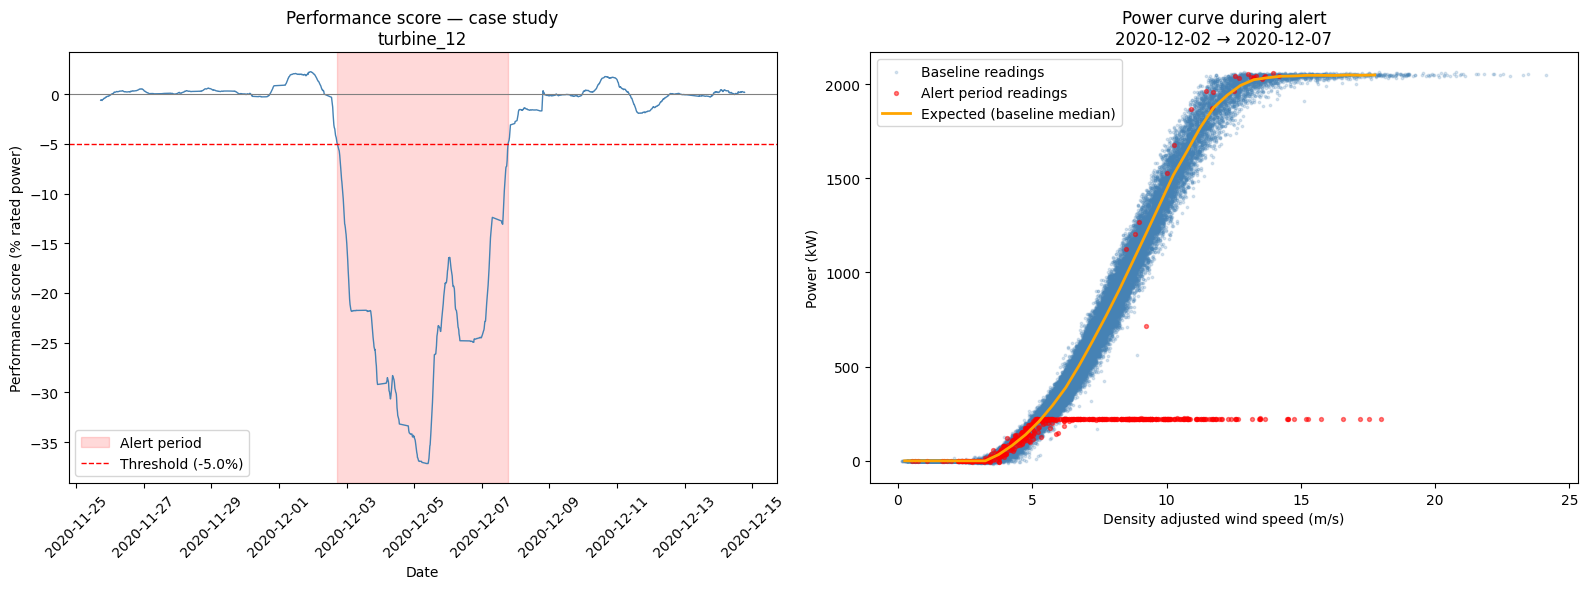


Case study summary — turbine_12
  Period     : 2020-12-02 → 2020-12-07
  Duration   : 121 hrs
  Mean score : -23.5% of rated power
  Worst score: -37.2% of rated power


In [179]:
for turbine in turbine_data_dictionary.keys():
    alert_periods = turbine_data_dictionary[turbine]["alert_periods"]
    scored        = turbine_data_dictionary[turbine]["scored"]
    baseline      = turbine_data_dictionary[turbine]["baseline"]
    baseline_curve = turbine_data_dictionary[turbine]["baseline_curve"]

    if alert_periods.empty:
        print(f"{turbine}: no sustained alerts to study")
        continue

    # Pick worst alert by mean score
    worst = alert_periods.loc[alert_periods["mean_score"].idxmin()]

    # Widen the window slightly for context
    window_start = worst["start"] - pd.Timedelta(days=7)
    window_end   = worst["end"]   + pd.Timedelta(days=7)

    scored_window = scored[
        (scored["# Date and time"] >= window_start) &
        (scored["# Date and time"] <= window_end)
    ]

    alert_readings = scored[
        (scored["# Date and time"] >= worst["start"]) &
        (scored["# Date and time"] <= worst["end"])
    ]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Left — performance score zoomed into the alert window
    axes[0].plot(
        scored_window["# Date and time"],
        scored_window["performance_score"],
        color="steelblue", linewidth=1
    )
    # ← remove the axhspan block entirely
    axes[0].axvspan(
        worst["start"], worst["end"],
        alpha=0.15, color="red", label="Alert period"
    )
    axes[0].axhline(ALERT_THRESHOLD, color="red", linestyle="--",
                    linewidth=1, label=f"Threshold ({ALERT_THRESHOLD}%)")
    axes[0].axhline(0, color="gray", linewidth=0.8)
    axes[0].set_xlabel("Date")
    axes[0].set_ylabel("Performance score (% rated power)")
    axes[0].set_title(f"Performance score — case study\n{turbine}")
    axes[0].legend()
    plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

    # Right — power curve during alert vs baseline
    axes[1].scatter(
        baseline["Density adjusted wind speed (m/s)"],
        baseline["Power (kW)"],
        s=3, alpha=0.2, color="steelblue", label="Baseline readings"
    )
    axes[1].scatter(
        alert_readings["Density adjusted wind speed (m/s)"],
        alert_readings["Power (kW)"],
        s=8, alpha=0.5, color="red", label="Alert period readings"
    )
    axes[1].plot(
        baseline_curve["ws_mid"], baseline_curve["median"],
        color="orange", linewidth=2, label="Expected (baseline median)"
    )
    axes[1].set_xlabel("Density adjusted wind speed (m/s)")
    axes[1].set_ylabel("Power (kW)")
    axes[1].set_title(
        f"Power curve during alert\n"
        f"{worst['start'].date()} → {worst['end'].date()}"
    )
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    print(f"\nCase study summary — {turbine}")
    print(f"  Period     : {worst['start'].date()} → {worst['end'].date()}")
    print(f"  Duration   : {worst['duration_hrs']:.0f} hrs")
    print(f"  Mean score : {worst['mean_score']:.1f}% of rated power")
    print(f"  Worst score: {worst['min_score']:.1f}% of rated power")

## 11.0 Generalisation and Scaling

### 11.1 What makes this approach reusable

The power curve monitor was deliberately designed to be failure-agnostic and 
farm-agnostic. It requires only four inputs that exist in any modern wind turbine 
SCADA system:

- Density adjusted wind speed (m/s)
- Power output (kW)
- A data availability flag
- A capacity or setpoint column to identify curtailment

It makes no assumptions about which component might fail, which failure modes are present, or what the site's historical fault patterns look like. The algorithm learns what "normal" looks like from the data itself during the baseline period, then flags deviations from that baseline. This means the same pipeline can be pointed at a farm with gearbox problems, a farm with blade fouling, or a farm with pitch misalignment - and it will surface underperformance in all three cases without modification.

### 11.2 Scaling to multiple turbines

The notebook already supports multiple turbines through the `TURBINES` constant and the `turbine_data_dictionary` loop structure. Running the full pipeline on all turbines at Penmanshiel requires a single change:

    TURBINES = ["01", "02", "03", "04", "05", "06", "07", "08", "09", "10", "11", "12", "13", "14"]

Each turbine gets its own baseline curve and its own performance score, which naturally handles turbines that have different operating histories or have been maintained at different times. Comparing performance scores across turbines also adds a second layer of signal: if all turbines at a farm underperform simultaneously, the cause is likely environmental (a measurement issue or site-wide condition) rather than a turbine-specific fault.

### 11.3 Scaling to multiple farms

Deploying to a new farm requires three things:

1. **Rated power** — derived automatically from `Available Capacity for Production (Planned) (kW)`, so no manual input is needed.
2. **A baseline window** — a clean period of at least three months with high availability and no active curtailment. In this analysis the window was chosen manually; in production this can be automated by identifying the longest contiguous high-availability period in the availability flag column.
3. **The same SCADA column names** — the `POWER_CURVE_FEATURES` list defines the interface contract. If a new farm uses different column names, only this list needs updating.

All constants (`BIN_WIDTH`, `MIN_BIN_COUNT`, `ROLLING_WINDOW`, `ALERT_THRESHOLD`) are farm-agnostic by design. `ALERT_THRESHOLD` is expressed as a percentage of rated power rather than absolute kW, so a −5% threshold means the same thing on a 2 MW turbine as on a 4 MW turbine.

### 11.4 Computational scaling

The scoring step is fully vectorised — it uses `pd.cut` and `Series.map` against an IntervalIndex lookup table rather than row-by-row iteration. This 
means scoring 200,000 readings takes milliseconds regardless of farm size. The most expensive step is the initial baseline computation, which runs once per turbine and is then stored. In a production deployment the baseline would be recomputed periodically (e.g. quarterly) and cached; the scoring pipeline would run on each new batch of SCADA data as it arrives.

## 12.0 Limitations and Next Steps

### 12.1 Limitations

**Single turbine demonstrated.** This analysis was carried out on turbine_12 only. The pipeline supports all turbines through the loop structure, but results have not been validated across the full fleet. Performance across turbines with different operational histories may surface edge cases in the baseline selection logic.

**Power curve monitoring detects underperformance, not failure cause.** The monitor flags that a turbine is producing less power than expected. It does not identify which component is responsible. A −23% performance score during the December 2020 alert period indicates significant degradation, but distinguishing between blade fouling, pitch misalignment, or a drivetrain fault requires additional signal analysis. This is by design for a first-layer monitor, but limits the actionability of an alert on its own.

**Baseline contamination risk.** If the chosen baseline window contains undetected gradual degradation, the monitor is calibrated to degraded 
performance rather than true healthy behaviour. The sanity check in section 10.1 (mean residual near zero during the baseline) partially mitigates this, but does not fully protect against slow pre-existing degradation.

**Nacelle anemometer accuracy.** The wind speed measurement comes from the nacelle-mounted anemometer, which sits in the turbine's own wake. This 
introduces a systematic bias that varies with wind direction and rotor operating state. A met mast or upstream reference anemometer would produce a 
cleaner wind speed signal. Density adjustment partially compensates, but direction-dependent bias remains.

**Fixed alert threshold.** The −5% threshold was chosen as an industry starting point rather than derived from the data. It does not adapt to turbines with naturally higher scatter in their power curves, and may produce more false positives on turbines operating in complex terrain with high turbulence.

**Manual baseline selection.** The Q3 2018 – Q2 2019 window was identified through EDA and cross-referencing the status log. In a production deployment serving many farms this would need to be automated.

### 12.2 Next Steps

**Normal behaviour modelling.** As stated in the objectives, the natural complement to power curve monitoring is a SCADA-based normal behaviour model 
using temperature, vibration, and electrical signals. Where the power curve monitor answers "is the turbine underperforming?", the normal behaviour model answers "which subsystem is behaving anomalously?". Together they form a two-stage diagnostic: the power curve monitor triggers an alert, and the normal behaviour model narrows the fault to a component. This is the second analytic proposed in section 3.0 and the logical next development.

**Extend to all turbines.** Run the full pipeline across all 14 turbines at Penmanshiel and compare performance scores. Cross-turbine comparison adds a valuable signal: simultaneous underperformance across multiple turbines suggests a site-level issue (measurement, grid, or environmental) whereas isolated underperformance on a single turbine points to a component fault.

**Automated baseline selection.** Replace the manual date bounds with an algorithm that identifies the longest contiguous window of high availability 
and zero curtailment. This removes the manual step that currently prevents fully automated deployment to a new farm.

**Data-driven threshold setting.** Derive the alert threshold from the empirical distribution of residuals during the baseline period, for example, 
flag when the rolling score falls below the 1st percentile of baseline performance. This makes the threshold adaptive to each turbine's natural 
variability rather than applying a fixed value across all turbines and farms.

**Seasonal baseline refresh.** Evaluate whether a rolling or seasonally updated baseline improves monitor sensitivity. Blade surface conditions and 
residual density-correction errors vary seasonally, which can cause slow drift in the baseline curve over time. A quarterly refresh cadence would 
reduce this drift without the cost of continuous retraining.